## Transient Background Modeling in CDS

This notebook demonstrates a background-modeling method for transients. Traditionally, one models the background by fitting the light curve before and after the burst. However, that approach only uses the count information after projecting to the `Time` axis. `cosipy` operates in Compton Data Space (CDS), so the background must be modeled in CDS as well. We therefore need a different approach that preserves the multi-dimensional structure of the data.

### Overview

The general idea is the same:

1. Define background windows before and after the burst.
2. Sum the data in those background windows and scale the result to the burst interval.

We provide two scaling methods: `duration` and `fitting`.

### Scaling Methods

#### `duration`

1. Convert the summed background model into a unit-rate background (i.e., a 1 s background).
2. Multiply by the burst duration so the expected total counts scale to the burst interval.

#### `fitting`
**This will be supported in the future.**

1. Fit the burst background level in a light curve using the background windows.
2. Use the fitted result to estimate the number of background counts in the burst interval.
3. Scale the summed background model to match the fitted counts.


In [1]:
from pathlib import Path
from histpy import Histogram
from cosipy import TransientBackgroundEstimation
import matplotlib.pyplot as plt

/home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/io/package_data.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


10:33:25 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=61544;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=964306;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=393329;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=85107;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=373945;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=581601;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

10:33:26 INFO      Starting 3ML!                                                                     ]8;id=730859;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=503300;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=961489;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=776172;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=253453;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=597734;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

10:33:28 WARNING   No fermitools installed                                              ]8;id=177985;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=577866;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

10:33:28 WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=762093;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=832430;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=642663;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=139023;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

## Load and examine data

In [2]:
data_dir = Path("")  # Current directory by default. Modify if you want a different path

In [3]:
# Read the data

file_name = "GRB_bn110605183_with_bkg.hdf5"

data = Histogram.open(data_dir / file_name)

In [4]:
# initialize background estimator

estimator = TransientBackgroundEstimation(data)

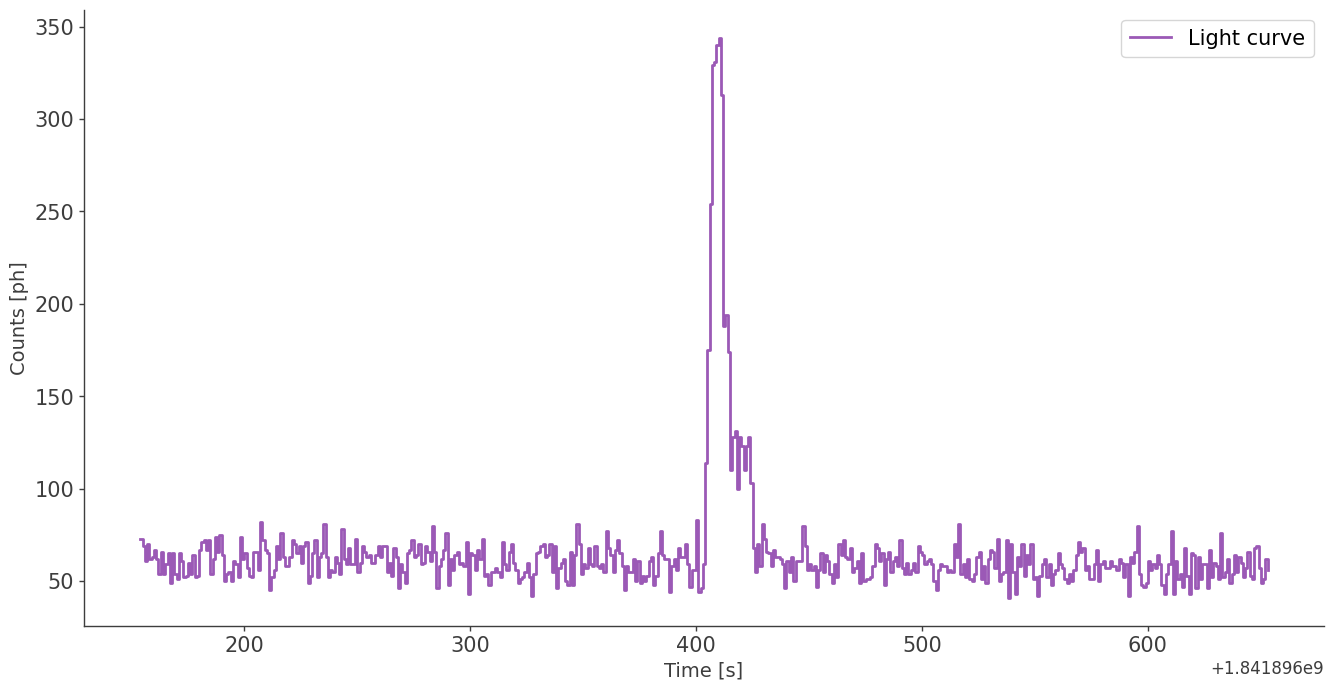

In [5]:
# view the full light curve
%matplotlib inline
estimator.plot_lightcurve()

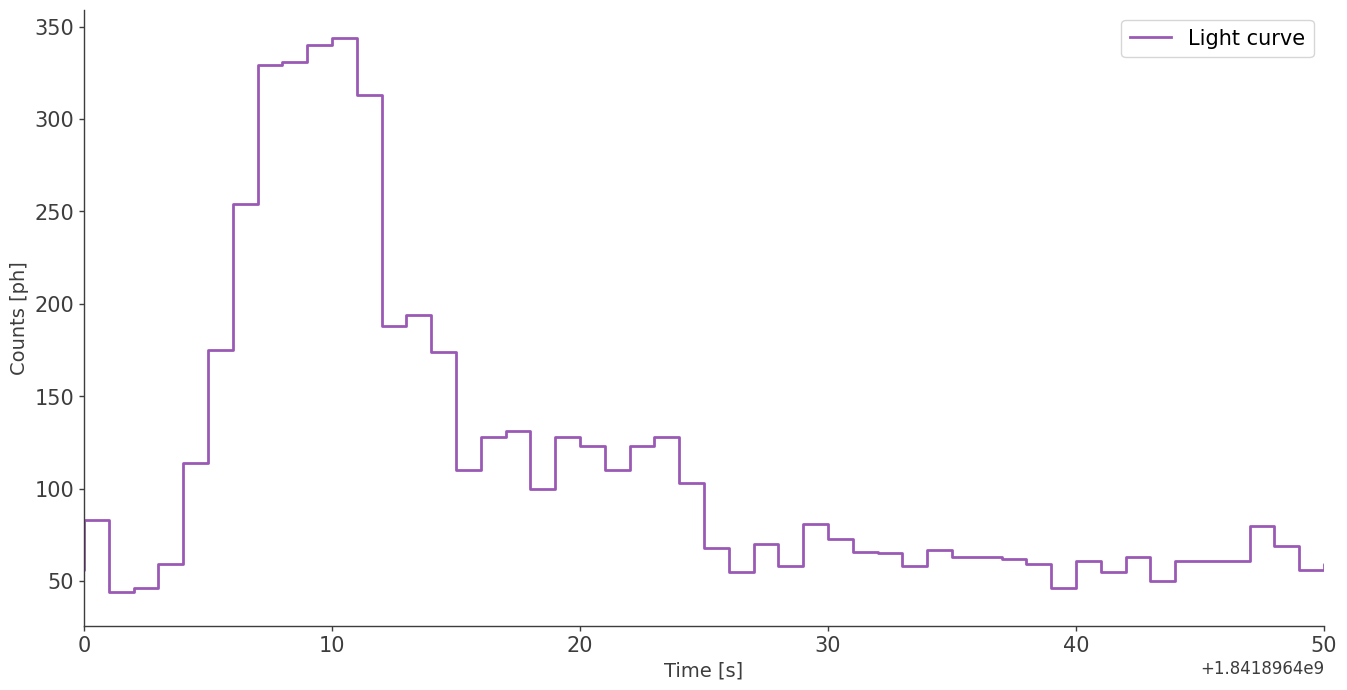

In [6]:
# You can zoom in the light curve by using `plot_limts` parameters
estimator.plot_lightcurve(plot_limits = [1.841896e9 + 400, 1.841896e9+450])

## Define Burst Window

You can estimate the burst window by the zoom-in light curve.

The burst windows can be recognized by Bayesian blocks. It will be implemented in future updates.

In [7]:
# add a burst window

estimator.add_burst_windows([1.8418964e9+4, 1.8418964e9+48])

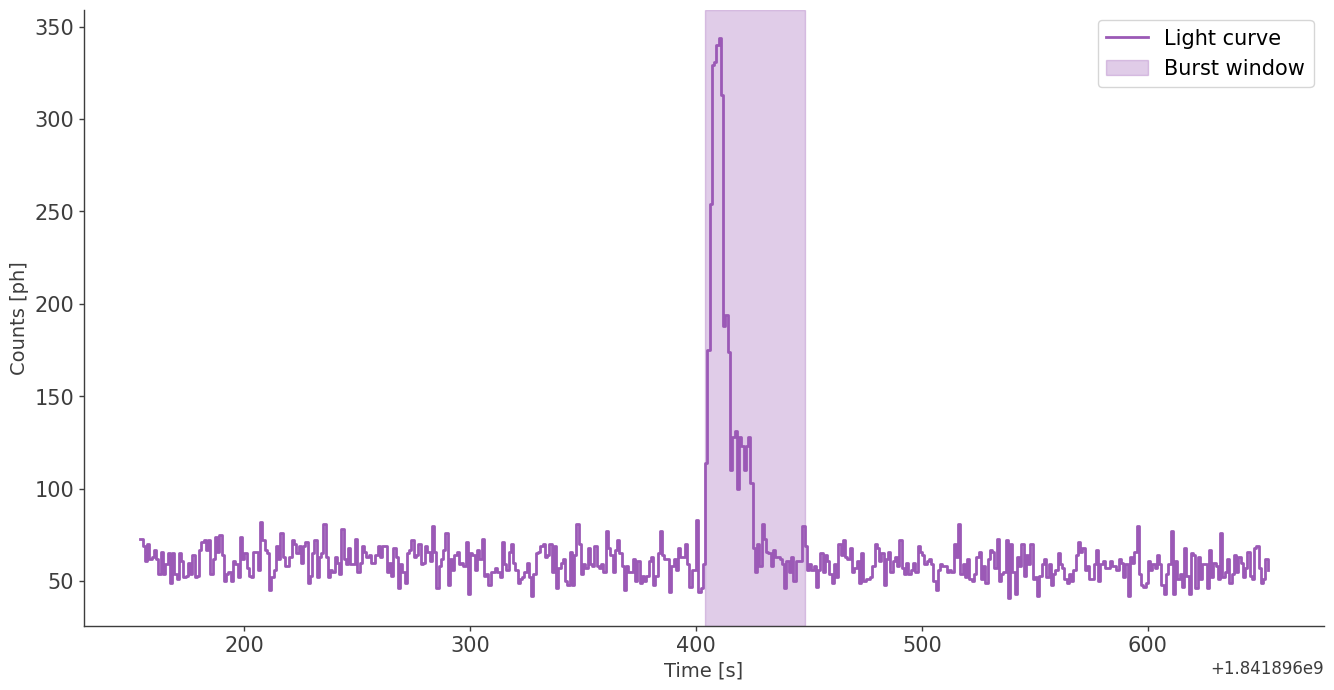

In [8]:
# plot the light curve with the burst window
estimator.plot_lightcurve(burst_windows=True)

## Define Background Windows

You can define the background windows like you did for the burst window.

In [9]:
estimator.add_bkg_windows([1.841896e9+200, 1.841896e9+300], [1.841896e9+500, 1.841896e9+600])

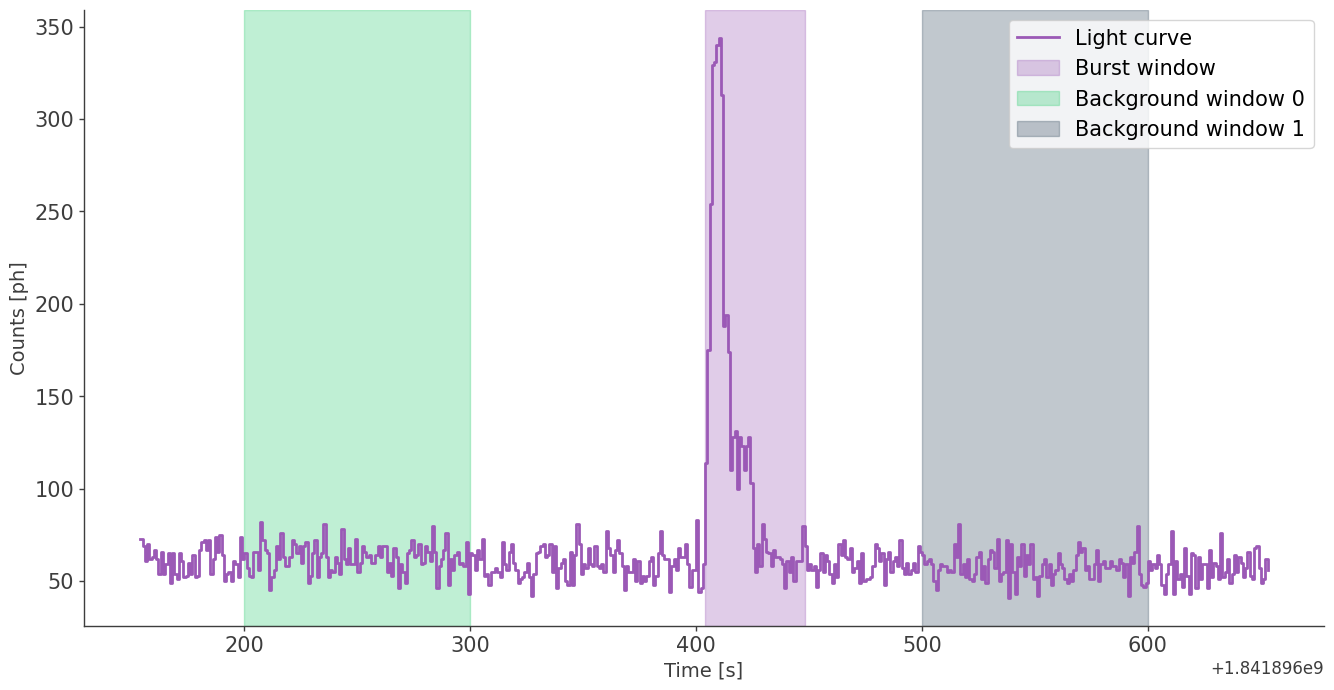

In [10]:
estimator.plot_lightcurve(burst_windows=True, bkg_windows=True)

## Make the background model

In [11]:
bkg_model = estimator.make_background_model()

Could not determine default ax_kw['coord']. WCSAxes do not support intricsic coordinates <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>. Fallling back to plotting onto ICRS coodinates
Failed to transform from 'spacecraftframe' to 'icrs'. Rasterizing in 'spacecraftframe' frame. ERROR: Spacecraft coordinates need attitude to transform from ICRS


Text(0.5, 1.0, 'Background model (PsiChi)')

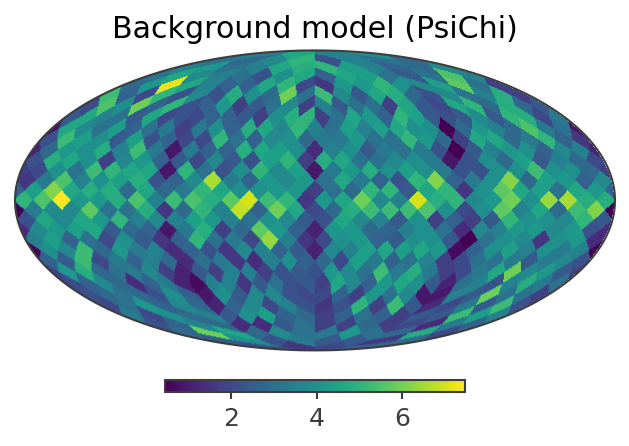

In [12]:
bkg_model.project("PsiChi").plot()
plt.title("Background model (PsiChi)")

## Compare with the true background

Could not determine default ax_kw['coord']. WCSAxes do not support intricsic coordinates <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>. Fallling back to plotting onto ICRS coodinates
Failed to transform from 'spacecraftframe' to 'icrs'. Rasterizing in 'spacecraftframe' frame. ERROR: Spacecraft coordinates need attitude to transform from ICRS


Text(0.5, 1.0, 'Real background (PsiChi)')

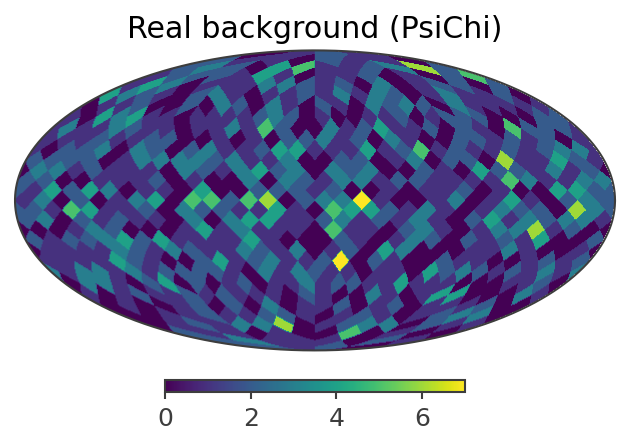

In [13]:
bkg_true = Histogram.open("True_GRB_bn110605183_background.hdf5")
bkg_true.project("PsiChi").plot()
plt.title("Real background (PsiChi)")

Could not determine default ax_kw['coord']. WCSAxes do not support intricsic coordinates <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>. Fallling back to plotting onto ICRS coodinates
Failed to transform from 'spacecraftframe' to 'icrs'. Rasterizing in 'spacecraftframe' frame. ERROR: Spacecraft coordinates need attitude to transform from ICRS


Text(0.5, 1.0, 'Real background (PsiChi)')

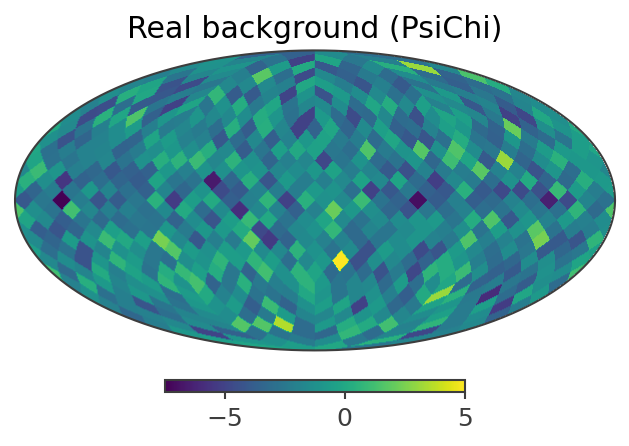

In [14]:
bkg_diff = bkg_true.project("PsiChi") - bkg_model.project("PsiChi")

bkg_diff.plot()
plt.title("Real background (PsiChi)")

The difference map is centered around $0$ with variations up to $\pm5$